# Task 2 – Content Type Analysis Dashboard
**Auspify Technologies – Data Analysis Using Python Internship**

**Goal:** Analyze the distribution of Movies and TV Shows available on Netflix.

**Workflow:** Load cleaned data → Count Movies & TV Shows → Visualize distribution → Compare proportions → Summarize key findings

## Step 1: Load the cleaned dataset
The input is `netflix_cleaned.csv`, produced in Task 1.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
COLORS = {'Movie': '#E50914', 'TV Show': '#221F1F'}   # Netflix red / black
os.makedirs('charts', exist_ok=True)

# Works from the repo layout (../Task1/) or with a local copy
path = '../Task1/netflix_cleaned.csv' if os.path.exists('../Task1/netflix_cleaned.csv') else 'netflix_cleaned.csv'
df = pd.read_csv(path, parse_dates=['date_added'])
print('Loaded:', path)
print('Shape:', df.shape)
df[['type', 'title', 'country', 'release_year', 'year_added', 'rating', 'rating_group', 'duration']].head()

Loaded: ../Task1/netflix_cleaned.csv
Shape: (8786, 15)


,type,title,country,release_year,year_added,rating,rating_group,duration
0,Movie,Dick Johnson Is Dead,United States,2020,2021,PG-13,Teens,90 min
1,TV Show,Ganglands,France,2021,2021,TV-MA,Adults,1 Season
2,TV Show,Midnight Mass,United States,2021,2021,TV-MA,Adults,1 Season
3,Movie,Confessions of an Invisible Girl,Brazil,2021,2021,TV-PG,Older Kids,91 min
4,Movie,Sankofa,United States,1993,2021,TV-MA,Adults,125 min


In [2]:
print('Missing values:', df.isnull().sum().sum())
print('Content types:', df['type'].unique().tolist())

Missing values: 0
Content types: ['Movie', 'TV Show']


## Step 2: Calculate the total number of Movies and TV Shows

In [3]:
counts = df['type'].value_counts()
pct = (counts / len(df) * 100).round(2)

summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
summary.loc['Total'] = [counts.sum(), pct.sum().round(2)]
summary['Count'] = summary['Count'].astype(int)
print(f"Total titles : {len(df):,}")
print(f"Movies       : {counts['Movie']:,}  ({pct['Movie']}%)")
print(f"TV Shows     : {counts['TV Show']:,}  ({pct['TV Show']}%)")
print(f"Movies per TV Show: {counts['Movie'] / counts['TV Show']:.2f}")
summary

Total titles : 8,786
Movies       : 6,123  (69.69%)
TV Shows     : 2,663  (30.31%)
Movies per TV Show: 2.30


,Count,Percentage (%)
type,,
Movie,6123,69.69
TV Show,2663,30.31
Total,8786,100.00


## Step 3: Create visualizations for content distribution
### 3.1 Bar chart – number of Movies vs TV Shows

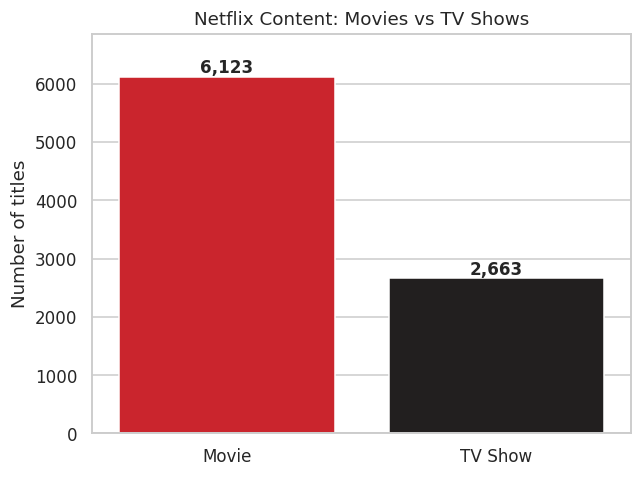

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.countplot(data=df, x='type', order=counts.index, hue='type', palette=COLORS, legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Netflix Content: Movies vs TV Shows')
ax.set_xlabel('')
ax.set_ylabel('Number of titles')
ax.set_ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.savefig('charts/01_type_count_bar.png', bbox_inches='tight')
plt.show()

### 3.2 Donut chart – share of each content type

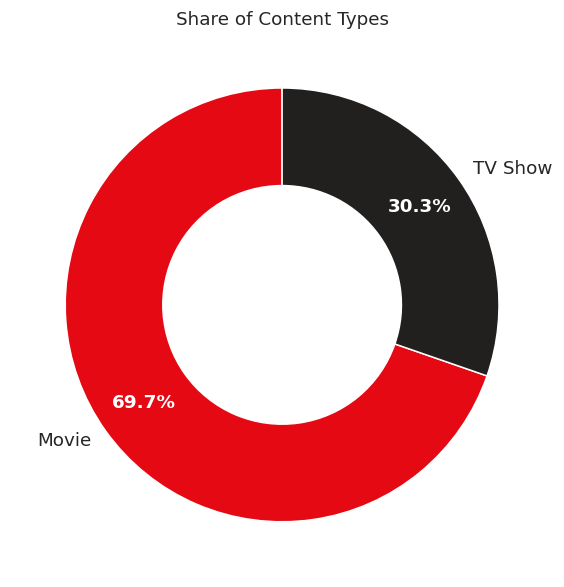

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
wedges, labels, autotexts = ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90,
       colors=[COLORS[t] for t in counts.index], wedgeprops={'width': 0.45, 'edgecolor': 'white'}, pctdistance=0.78, labeldistance=1.08)
plt.setp(autotexts, color='white', fontsize=12, fontweight='bold')
plt.setp(labels, fontsize=12)
ax.set_title('Share of Content Types')
plt.tight_layout()
plt.savefig('charts/02_type_share_donut.png', bbox_inches='tight')
plt.show()

### 3.3 Titles added to Netflix each year, by type

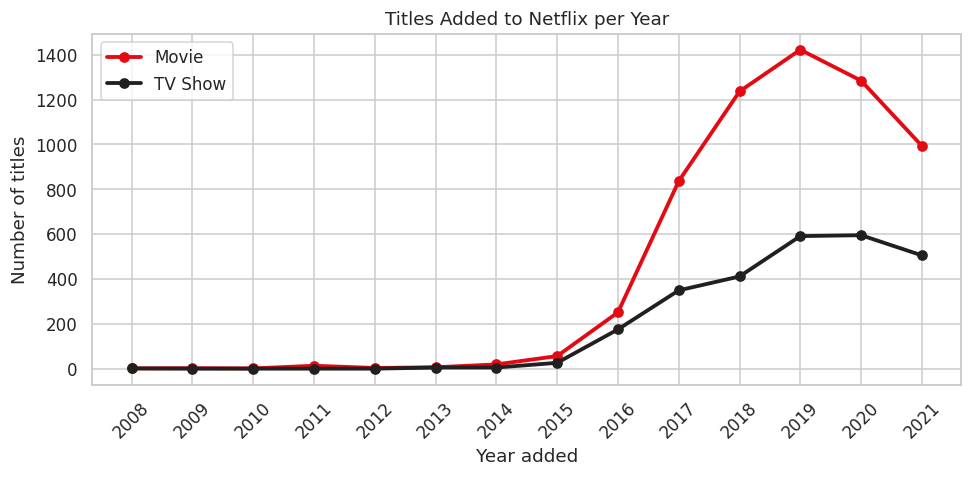

type,Movie,TV Show
year_added,,
2014,19,5
2015,56,26
2016,251,175
2017,836,349
2018,1236,411
2019,1422,591
2020,1284,595
2021,993,505


In [6]:
added = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
for t in ['Movie', 'TV Show']:
    ax.plot(added.index, added[t], marker='o', linewidth=2.5, color=COLORS[t], label=t)
ax.set_title('Titles Added to Netflix per Year')
ax.set_xlabel('Year added')
ax.set_ylabel('Number of titles')
ax.set_xticks(added.index)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_added_per_year.png', bbox_inches='tight')
plt.show()
added.tail(8)

*Note: the dataset ends in September 2021, so 2021 is a partial year.*

### 3.4 Movie length and TV Show seasons

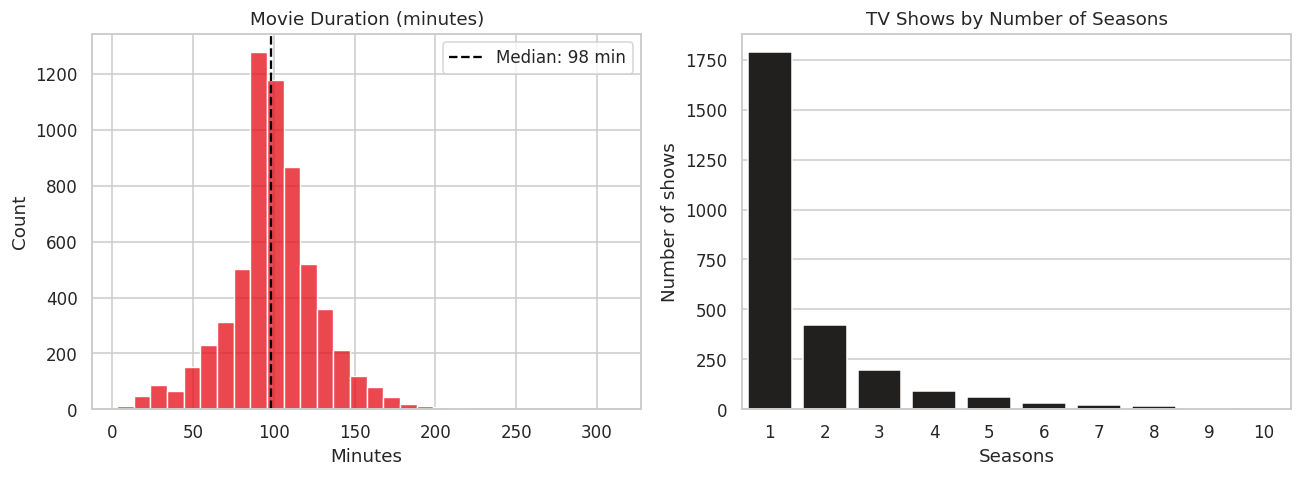

Median movie length : 98 minutes
TV Shows with 1 season: 67.2%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

movies = df[df['type'] == 'Movie']
sns.histplot(movies['duration_value'], bins=30, color=COLORS['Movie'], ax=axes[0])
axes[0].axvline(movies['duration_value'].median(), color='black', linestyle='--', label=f"Median: {movies['duration_value'].median():.0f} min")
axes[0].set_title('Movie Duration (minutes)')
axes[0].set_xlabel('Minutes')
axes[0].legend()

shows = df[df['type'] == 'TV Show']
season_counts = shows['duration_value'].value_counts().sort_index()
season_counts = season_counts[season_counts.index <= 10]
sns.barplot(x=season_counts.index, y=season_counts.values, color=COLORS['TV Show'], ax=axes[1])
axes[1].set_title('TV Shows by Number of Seasons')
axes[1].set_xlabel('Seasons')
axes[1].set_ylabel('Number of shows')

plt.tight_layout()
plt.savefig('charts/04_duration_distribution.png', bbox_inches='tight')
plt.show()

print(f"Median movie length : {movies['duration_value'].median():.0f} minutes")
print(f"TV Shows with 1 season: {(shows['duration_value'] == 1).mean() * 100:.1f}%")

## Step 4: Compare content proportions
### 4.1 Movie vs TV Show share by release decade

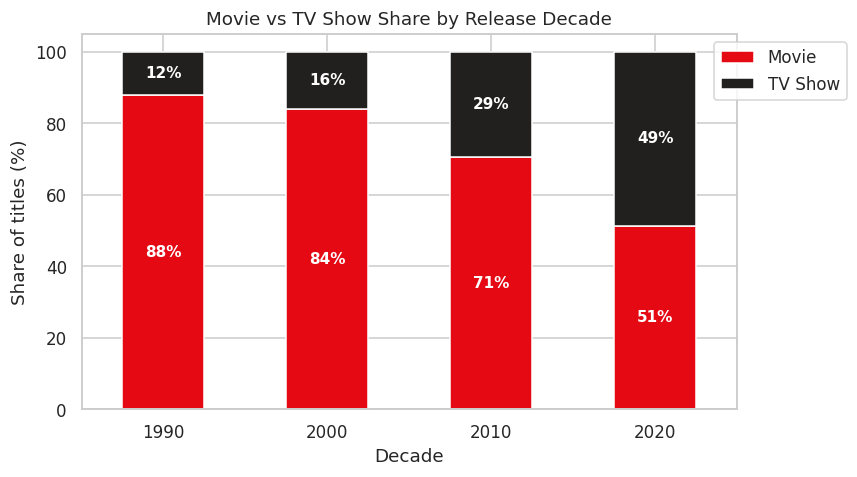

type,Movie,TV Show
decade,,
1990,241,33
2000,677,130
2010,4176,1733
2020,794,751


In [8]:
df['decade'] = (df['release_year'] // 10 * 10).astype(int)
recent = df[df['decade'] >= 1990]

by_decade = pd.crosstab(recent['decade'], recent['type'])
by_decade_pct = by_decade.div(by_decade.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
by_decade_pct[['Movie', 'TV Show']].plot(kind='bar', stacked=True, color=[COLORS['Movie'], COLORS['TV Show']], ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=10, fontweight='bold')
ax.set_title('Movie vs TV Show Share by Release Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Share of titles (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='', loc='upper right', bbox_to_anchor=(1.18, 1))
plt.tight_layout()
plt.savefig('charts/05_share_by_decade.png', bbox_inches='tight')
plt.show()
by_decade

### 4.2 Audience rating group by content type

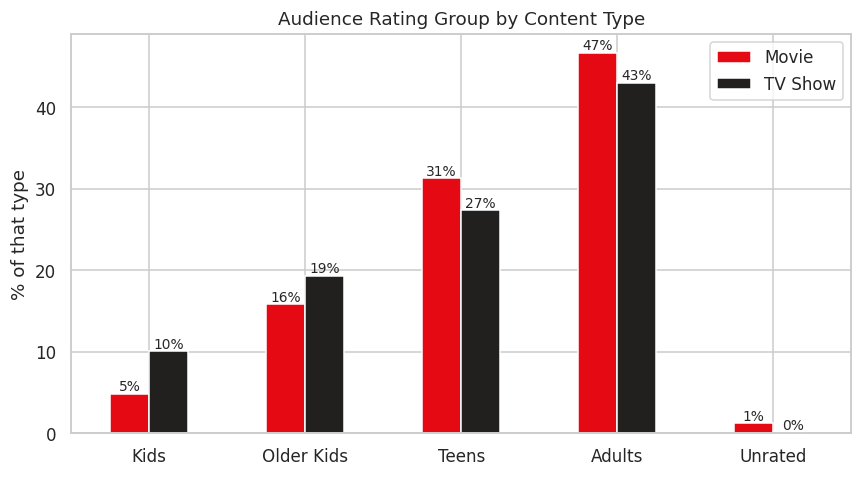

rating_group,Kids,Older Kids,Teens,Adults,Unrated
type,,,,,
Movie,4.9,15.9,31.3,46.7,1.3
TV Show,10.1,19.4,27.4,43.0,0.2


In [9]:
order = ['Kids', 'Older Kids', 'Teens', 'Adults', 'Unrated']
rg = pd.crosstab(df['type'], df['rating_group'], normalize='index')[order] * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
rg.T.plot(kind='bar', color=[COLORS['Movie'], COLORS['TV Show']], ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', fontsize=9)
ax.set_title('Audience Rating Group by Content Type')
ax.set_xlabel('')
ax.set_ylabel('% of that type')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.savefig('charts/06_rating_group_by_type.png', bbox_inches='tight')
plt.show()
rg.round(1)

### 4.3 Share of TV Shows over time (by year added)

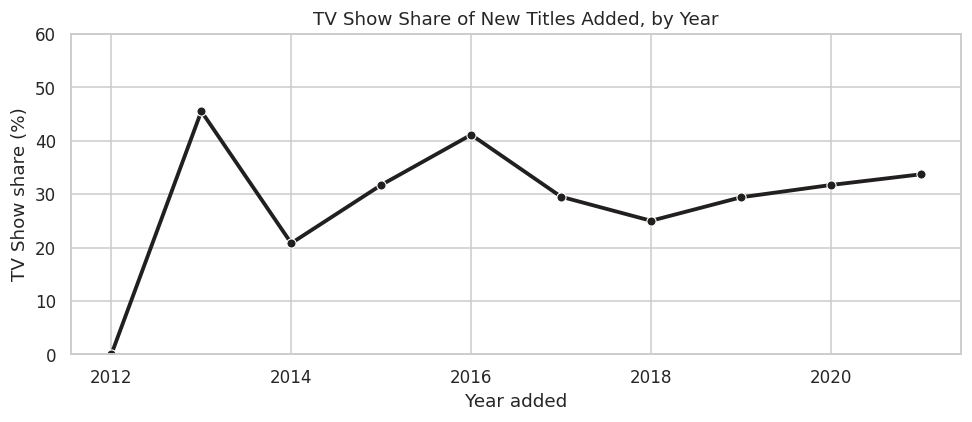

,year_added,tv_show_share_pct
6,2014,20.8
7,2015,31.7
8,2016,41.1
9,2017,29.5
10,2018,25.0
11,2019,29.4
12,2020,31.7
13,2021,33.7


In [10]:
share = (added['TV Show'] / added.sum(axis=1) * 100).round(1)
share_df = share.reset_index()
share_df.columns = ['year_added', 'tv_show_share_pct']

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=share_df[share_df['year_added'] >= 2012], x='year_added', y='tv_show_share_pct', marker='o', color=COLORS['TV Show'], linewidth=2.5, ax=ax)
ax.set_title('TV Show Share of New Titles Added, by Year')
ax.set_xlabel('Year added')
ax.set_ylabel('TV Show share (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('charts/07_tv_share_over_time.png', bbox_inches='tight')
plt.show()
share_df.tail(8)

## Step 5: Dashboard and key findings
### Combined dashboard

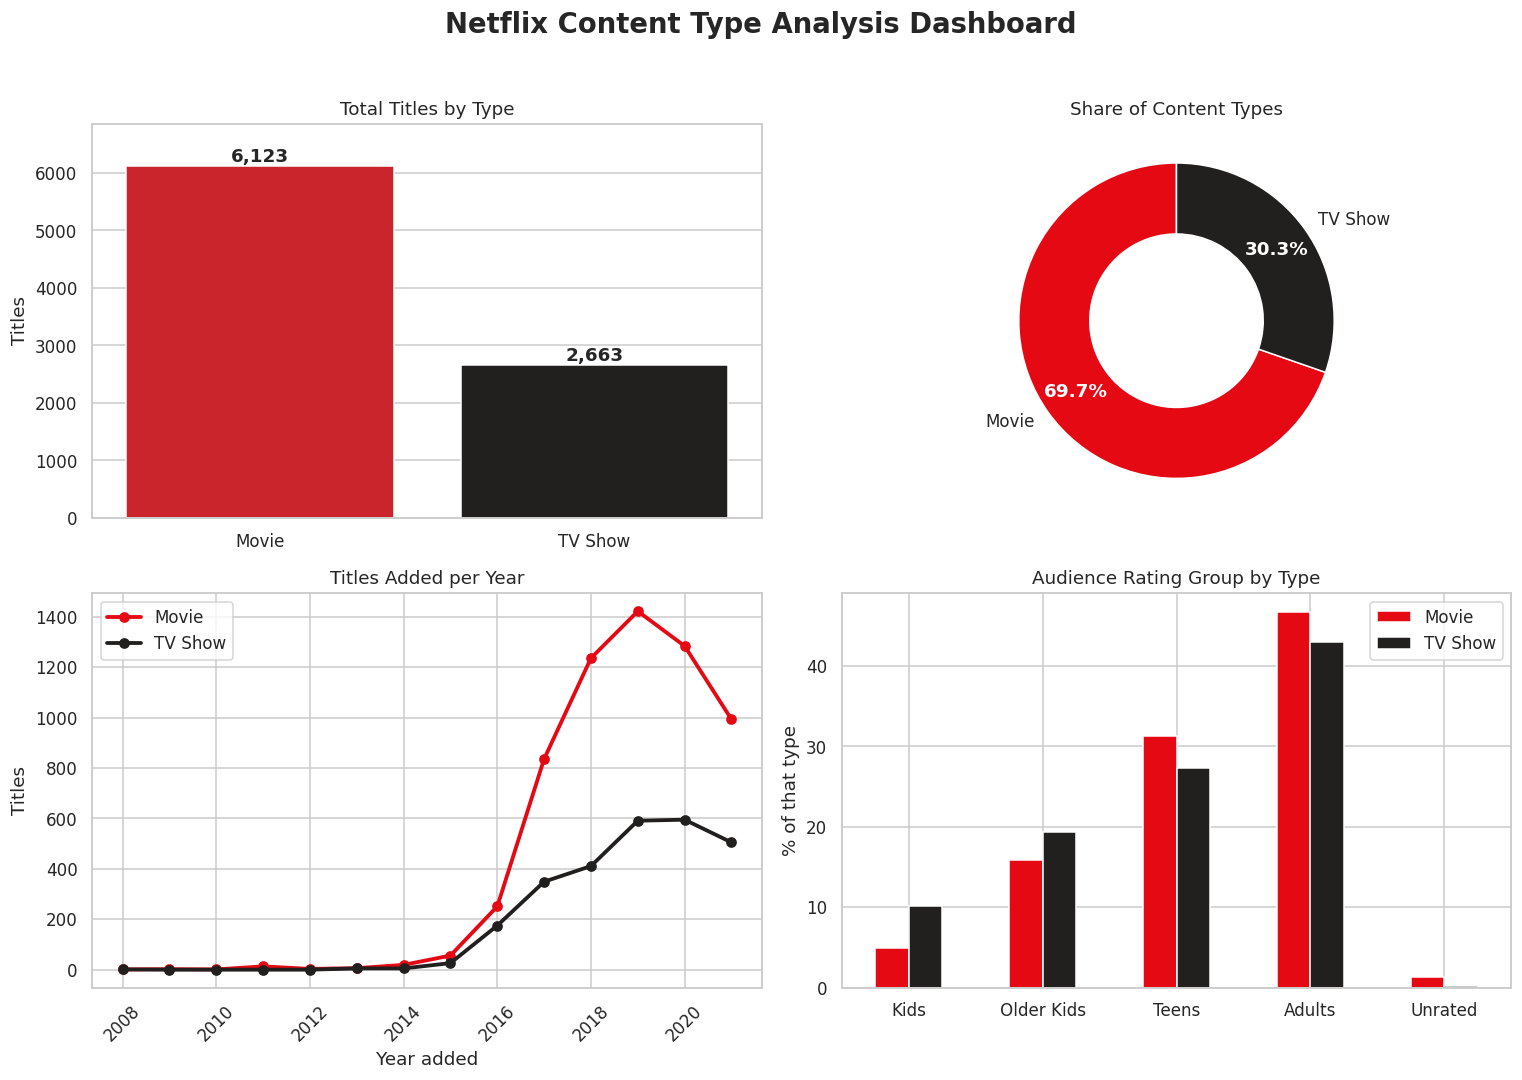

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Netflix Content Type Analysis Dashboard', fontsize=18, fontweight='bold')

# 1. Count
sns.countplot(data=df, x='type', order=counts.index, hue='type', palette=COLORS, legend=False, ax=axes[0, 0])
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_title('Total Titles by Type')
axes[0, 0].set_xlabel(''); axes[0, 0].set_ylabel('Titles')
axes[0, 0].set_ylim(0, counts.max() * 1.12)

# 2. Donut
w, l, at = axes[0, 1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=[COLORS[t] for t in counts.index],
               wedgeprops={'width': 0.45, 'edgecolor': 'white'}, pctdistance=0.78)
plt.setp(at, color='white', fontsize=12, fontweight='bold')
plt.setp(l, fontsize=11)
axes[0, 1].set_title('Share of Content Types')

# 3. Per year
for t in ['Movie', 'TV Show']:
    axes[1, 0].plot(added.index, added[t], marker='o', linewidth=2.5, color=COLORS[t], label=t)
axes[1, 0].set_title('Titles Added per Year')
axes[1, 0].set_xlabel('Year added'); axes[1, 0].set_ylabel('Titles')
axes[1, 0].tick_params(axis='x', rotation=45); axes[1, 0].legend()

# 4. Rating group
rg.T.plot(kind='bar', color=[COLORS['Movie'], COLORS['TV Show']], ax=axes[1, 1])
axes[1, 1].set_title('Audience Rating Group by Type')
axes[1, 1].set_xlabel(''); axes[1, 1].set_ylabel('% of that type')
axes[1, 1].tick_params(axis='x', rotation=0); axes[1, 1].legend(title='')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('charts/08_dashboard.png', bbox_inches='tight')
plt.show()

### Key findings (calculated from the data)

In [12]:
peak_year = added.sum(axis=1).idxmax()
full = added[added.index < 2021]
movie_peak = full['Movie'].idxmax()
tv_peak = full['TV Show'].idxmax()
adults_movie = rg.loc['Movie', 'Adults']
adults_tv = rg.loc['TV Show', 'Adults']
kids_movie = rg.loc['Movie', 'Kids'] + rg.loc['Movie', 'Older Kids']
kids_tv = rg.loc['TV Show', 'Kids'] + rg.loc['TV Show', 'Older Kids']

print('KEY FINDINGS')
print('-' * 60)
print(f"1. Netflix has {len(df):,} titles: {counts['Movie']:,} Movies ({pct['Movie']}%) and {counts['TV Show']:,} TV Shows ({pct['TV Show']}%).")
print(f"2. There are about {counts['Movie'] / counts['TV Show']:.1f} Movies for every TV Show.")
print(f"3. Movie additions peaked in {movie_peak} ({full.loc[movie_peak, 'Movie']:,} titles); TV Show additions peaked in {tv_peak} ({full.loc[tv_peak, 'TV Show']:,} titles).")
print(f"4. The median movie runs {movies['duration_value'].median():.0f} minutes; {(shows['duration_value'] == 1).mean() * 100:.0f}% of TV Shows have only 1 season.")
print(f"5. Adult-rated content is {adults_movie:.0f}% of Movies and {adults_tv:.0f}% of TV Shows; content for kids/older kids is {kids_movie:.0f}% of Movies and {kids_tv:.0f}% of TV Shows.")
print(f"6. TV Shows made up {share[share.index == 2020].iloc[0]:.0f}% of titles added in 2020, versus {share[share.index == 2016].iloc[0]:.0f}% in 2016.")

KEY FINDINGS
------------------------------------------------------------
1. Netflix has 8,786 titles: 6,123 Movies (69.69%) and 2,663 TV Shows (30.31%).
2. There are about 2.3 Movies for every TV Show.
3. Movie additions peaked in 2019 (1,422 titles); TV Show additions peaked in 2020 (595 titles).
4. The median movie runs 98 minutes; 67% of TV Shows have only 1 season.
5. Adult-rated content is 47% of Movies and 43% of TV Shows; content for kids/older kids is 21% of Movies and 29% of TV Shows.
6. TV Shows made up 32% of titles added in 2020, versus 41% in 2016.


## Business insights
- **Movies dominate the catalogue** (roughly 7 in 10 titles), so Netflix's library depth is mostly film.
- **TV Shows are a smaller but steady slice**, and most have just one season, which suggests many limited series or shows that are not renewed.
- **Additions grew sharply from 2016 to 2019.** Movie additions peaked in 2019 and dipped in 2020, while TV Show additions kept rising until 2020 (2021 is a partial year).
- **Adult-oriented content is the largest audience group** for both types (47% of Movies, 43% of TV Shows). TV Shows lean a little more toward kids and older kids (29% vs 21% of Movies).
- **Recommendation:** keep investing in movies for catalogue breadth, but track TV Show retention (season renewals) because it drives long-term subscriber engagement.

*Insights come from this dataset only (titles up to September 2021) and describe the catalogue, not viewing numbers.*

## Summary
| Item | Result |
|---|---|
| Dataset | `netflix_cleaned.csv` (8,786 titles) |
| Charts created | Bar, donut, line (per year), histogram and season chart, stacked decade share, rating-group comparison, TV share trend, combined dashboard |
| Charts saved | `Task2/charts/` (8 PNG files) |
| Skills used | Pandas GroupBy / crosstab, Matplotlib, Seaborn, EDA |